In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from google.colab import drive

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Dense,
    LayerNormalization,
    MultiHeadAttention,
    Add,
    GlobalAveragePooling1D,
    Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## Project Methodology Pipeline
The overall project pipeline is illustrated below:

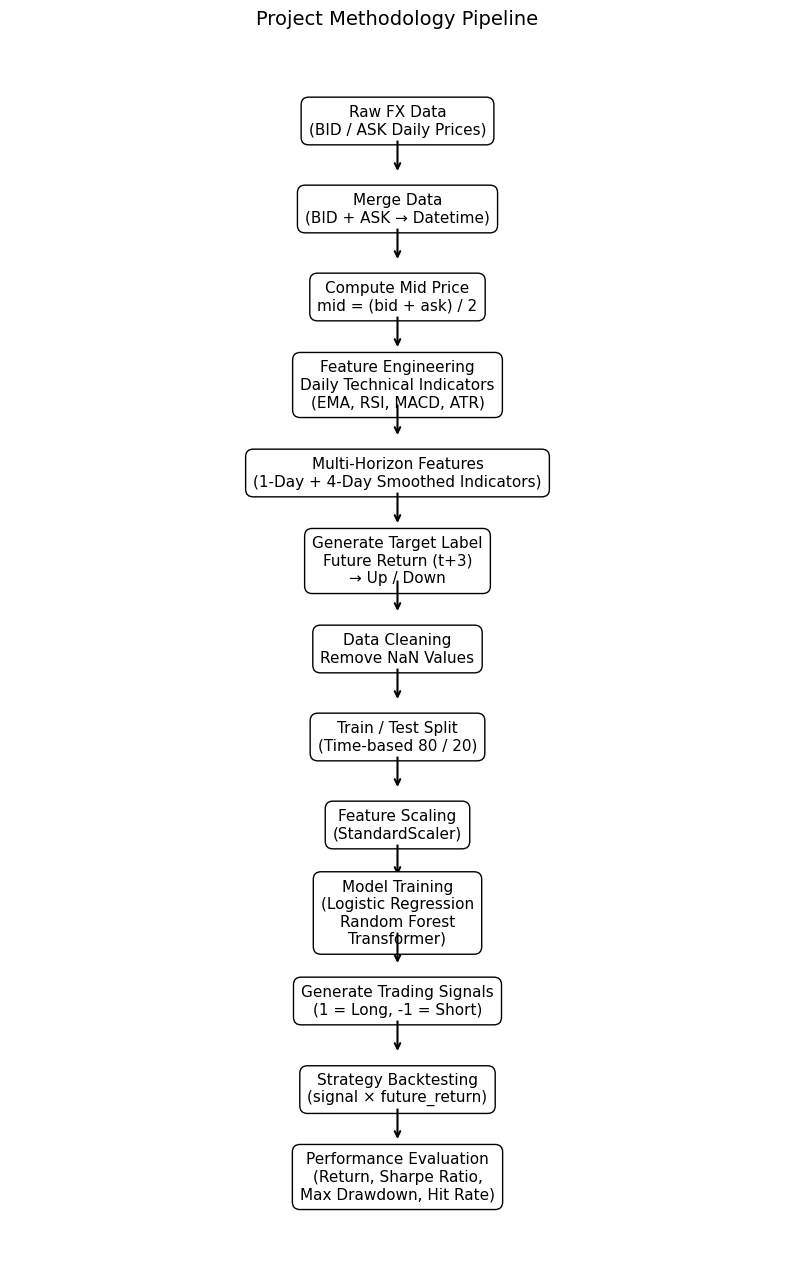

In [ ]:
steps = [
    "Raw FX Data\n(BID / ASK Daily Prices)",
    "Merge Data\n(BID + ASK → Datetime)",
    "Compute Mid Price\nmid = (bid + ask) / 2",
    "Feature Engineering\nDaily Technical Indicators\n(EMA, RSI, MACD, ATR)",
    "Multi-Horizon Features\n(1-Day + 4-Day Smoothed Indicators)",
    "Generate Target Label\nFuture Return (t+3)\n→ Up / Down",
    "Data Cleaning\nRemove NaN Values",
    "Train / Test Split\n(Time-based 80 / 20)",
    "Feature Scaling\n(StandardScaler)",
    "Model Training\n(Logistic Regression\nRandom Forest\nTransformer)",
    "Generate Trading Signals\n(1 = Long, -1 = Short)",
    "Strategy Backtesting\n(signal × future_return)",
    "Performance Evaluation\n(Return, Sharpe Ratio,\nMax Drawdown, Hit Rate)"
]

fig, ax = plt.subplots(figsize=(10, 16))
ax.axis("off")

y_positions = list(range(len(steps), 0, -1))

for i, (step, y) in enumerate(zip(steps, y_positions)):
    ax.text(
        0.5, y, step,
        ha="center", va="center",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5", edgecolor="black", facecolor="white")
    )
    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(0.5, y - 0.6),
            xytext=(0.5, y - 0.2),
            arrowprops=dict(arrowstyle="->", lw=1.5)
        )

ax.set_xlim(0, 1)
ax.set_ylim(0, len(steps) + 1)

plt.title("Project Methodology Pipeline", fontsize=14)
plt.show()

# **1. Data Layer**

The dataset used in this study consists of daily USD/JPY foreign exchange market data, including bid and ask prices.

The dataset contains the following variables:

*   Datetime
*   Open Price
*   High Price
*   Low Price
*   Close Price
*   Volume

To represent the market price more accurately, a mid-price was computed as:

𝑀𝑖𝑑𝑃𝑟𝑖𝑐𝑒 = 𝐵𝑖𝑑𝑃𝑟𝑖𝑐𝑒+𝐴𝑠𝑘𝑃𝑟𝑖𝑐𝑒 / 2

This mid-price series serves as the primary input for all feature engineering and modelling processes.

In [ ]:
# =========================================================
# NOTE ON DATA PATH (IMPORTANT FOR REPRODUCIBILITY)
# =========================================================
# This project was developed using Google Colab with Google Drive integration.
# The dataset is stored in the author's personal Google Drive directory.
#
# To run this code on another machine, please update the following paths:
# - BID_DATA_PATH
# - ASK_DATA_PATH
#
# Users may either:
# 1. Upload the dataset to their own Google Drive and modify the paths accordingly, OR
# 2. Replace the paths with local file system paths (e.g., "C:/data/" or "./data/")
#
# Example (local path):
# BID_DATA_PATH = "./data/BID"
# ASK_DATA_PATH = "./data/ASK"
#
# =========================================================

drive.mount('/content/drive')

BID_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/DataScienceProject/Data/BID"
ASK_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/DataScienceProject/Data/ASK"

print("Contents of BID data folder:")
print(os.listdir(BID_DATA_PATH))

print("\nContents of ASK data folder:")
print(os.listdir(ASK_DATA_PATH))

# ---------------------------------------------------
#  Read BID Data
# ---------------------------------------------------

bid_files = sorted([
    os.path.join(BID_DATA_PATH, f)
    for f in os.listdir(BID_DATA_PATH)
    if f.endswith(".csv")
])

bid_df_list = []
for f in bid_files:
    print("Loading BID:", f)
    bid_df_list.append(pd.read_csv(f))

bid = pd.concat(bid_df_list, ignore_index=True)


# ---------------------------------------------------
# Read ASK Data
# ---------------------------------------------------

ask_files = sorted([
    os.path.join(ASK_DATA_PATH, f)
    for f in os.listdir(ASK_DATA_PATH)
    if f.endswith(".csv")
])

ask_df_list = []
for f in ask_files:
    print("Loading ASK:", f)
    ask_df_list.append(pd.read_csv(f))

ask = pd.concat(ask_df_list, ignore_index=True)


# ---------------------------------------------------
# Standardize datetime
# ---------------------------------------------------

bid.rename(columns={bid.columns[0]: "datetime"}, inplace=True)
ask.rename(columns={ask.columns[0]: "datetime"}, inplace=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Contents of BID data folder:
['USD-JPY_Day_2024-01-01_to_2024-12-31_Asia_Kuala_Lumpur.csv', 'USD-JPY_Day_2023-01-01_to_2023-12-31_Asia_Kuala_Lumpur.csv', 'USD-JPY_Day_2022-01-01_to_2022-12-31_Asia_Kuala_Lumpur.csv', 'USD-JPY_Day_2021-01-01_to_2021-12-31_Asia_Kuala_Lumpur.csv', 'USD-JPY_Day_2020-01-01_to_2020-12-31_Asia_Kuala_Lumpur.csv', 'USD-JPY_Day_2019-01-01_to_2019-12-31_Asia_Kuala_Lumpur.csv', 'USD-JPY_Day_2018-01-01_to_2018-12-31_Asia_Kuala_Lumpur.csv', 'USD-JPY_Day_2017-01-01_to_2017-12-31_Asia_Kuala_Lumpur.csv', 'USD-JPY_Day_2016-01-01_to_2016-12-31_Asia_Kuala_Lumpur.csv', 'USD-JPY_Day_2025-01-01_to_2025-12-31_Asia_Kuala_Lumpur.csv']

Contents of ASK data folder:
['USD-JPY_Day_2024-01-01_to_2024-12-31_Asia_Kuala_Lumpur.csv', 'USD-JPY_Day_2023-01-01_to_2023-12-31_Asia_Kuala_Lumpur.csv', 'USD-JPY_Day_2022-01-01_to_2022-12-31_Asia_Kuala_Lumpur.csv', 'USD

# 2. Data Preprocessing

The raw dataset was cleaned and prepared before modelling. The preprocessing steps include:

- Converting timestamps to datetime format  
- Sorting the data chronologically  
- Removing missing values generated during feature engineering  
- Creating a clean modelling dataset  

A **time-based split** was used to avoid look-ahead bias:

- First **80%** of the data → Training set  
- Last **20%** of the data → Testing set  

This ensures the models are evaluated on **future unseen data**.


In [ ]:
bid["datetime"] = bid["datetime"].astype(str).str.replace(" UTC\\+08:00", "", regex=True)
ask["datetime"] = ask["datetime"].astype(str).str.replace(" UTC\\+08:00", "", regex=True)

bid["datetime"] = pd.to_datetime(bid["datetime"], dayfirst=True)
ask["datetime"] = pd.to_datetime(ask["datetime"], dayfirst=True)

bid = bid[["datetime", "Close", "Volume"]].rename(
    columns={"Close": "bid_close", "Volume": "bid_volume"}
)
ask = ask[["datetime", "Close", "Volume"]].rename(
    columns={"Close": "ask_close", "Volume": "ask_volume"}
)

# merge
df = pd.merge(bid, ask, on="datetime", how="inner")

# mid-price & volume proxy
df["mid_price"] = (df["bid_close"] + df["ask_close"]) / 2
df["volume"] = (df["bid_volume"] + df["ask_volume"]) / 2

df = df.sort_values("datetime").reset_index(drop=True)

df

,datetime,bid_close,bid_volume,ask_close,ask_volume,mid_price,volume
0,2016-01-03,120.316,4554.27,120.320,3842.84,120.3180,4198.555
1,2016-01-04,119.469,146692.82,119.474,137851.82,119.4715,142272.320
2,2016-01-05,119.110,156293.90,119.115,151042.91,119.1125,153668.405
3,2016-01-06,118.622,178412.54,118.626,173533.93,118.6240,175973.235
4,2016-01-07,117.531,208172.34,117.533,195770.01,117.5320,201971.175
...,...,...,...,...,...,...,...
3122,2025-12-26,156.561,128778.90,156.592,114898.52,156.5765,121838.710
3123,2025-12-28,156.484,6307.07,156.488,6522.80,156.4860,6414.935
3124,2025-12-29,155.990,136000.49,155.997,123033.89,155.9935,129517.190
3125,2025-12-30,156.400,105883.26,156.404,113487.07,156.4020,109685.165


In [ ]:
# =========================
# Helper functions
# =========================

# Compute Exponential Moving Average (EMA)
def ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

# Compute Relative Strength Index (RSI)
def rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

# Compute MACD line, signal line, and histogram
def macd(series, fast=12, slow=26, signal=9):
    macd_line = ema(series, fast) - ema(series, slow)
    signal_line = ema(macd_line, signal)
    hist = macd_line - signal_line
    return macd_line, signal_line, hist

# Approximate ATR using rolling standard deviation as a volatility proxy
def atr_proxy(series, period=14):
    return series.rolling(period).std()

# Convert tabular features into sequential data for deep learning models
def make_sequences(X, y, lookback):
    X_seq, y_seq = [], []
    for i in range(lookback, len(X)):
        X_seq.append(X[i - lookback:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

# Calculate classification performance metrics
def model_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

# Compute annualized Sharpe Ratio for strategy returns
def sharpe_ratio(returns, periods_per_year=252):
    returns = np.asarray(returns)
    if len(returns) == 0 or np.std(returns) == 0:
        return 0.0
    return (np.mean(returns) / np.std(returns)) * np.sqrt(periods_per_year)

# Compute Maximum Drawdown from cumulative returns
def max_drawdown(cum_returns):
    cum_returns = np.asarray(cum_returns)
    running_max = np.maximum.accumulate(cum_returns)
    drawdown = cum_returns - running_max
    return drawdown.min()

# Compute Hit Rate: percentage of profitable trades
def hit_rate(returns):
    returns = np.asarray(returns)
    if len(returns) == 0:
        return 0.0
    return np.mean(returns > 0)

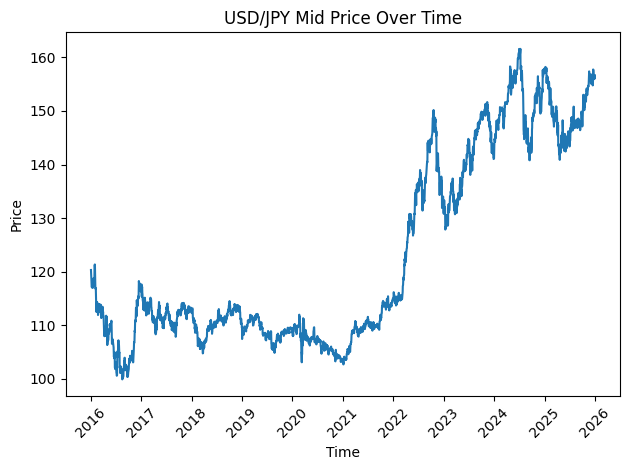

In [ ]:
plt.figure()
plt.plot(df["datetime"], df["mid_price"])
plt.title("USD/JPY Mid Price Over Time")
plt.xlabel("Time")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

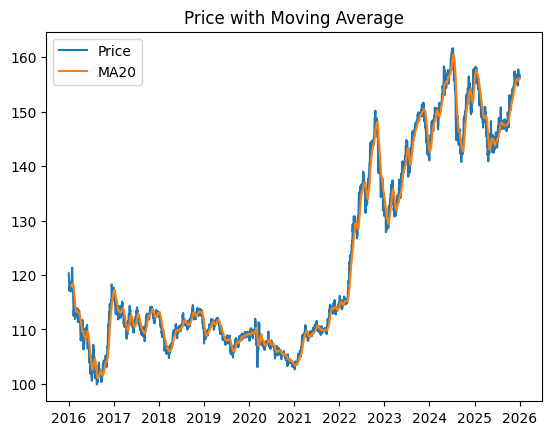

In [ ]:
df["ma_20"] = df["mid_price"].rolling(20).mean()

plt.figure()
plt.plot(df["datetime"], df["mid_price"], label="Price")
plt.plot(df["datetime"], df["ma_20"], label="MA20")
plt.legend()
plt.title("Price with Moving Average")
plt.show()

# 3. Feature Engineering

Technical indicators were generated from the mid-price time series to capture market behaviour.

These indicators represent key market characteristics such as trend, momentum, and volatility.

## Daily indicators

The following daily indicators were used:

- EMA10 (10-day Exponential Moving Average)  
- EMA30 (30-day Exponential Moving Average)  
- RSI (Relative Strength Index)  
- MACD  
- MACD Signal  
- ATR (Average True Range proxy)

These indicators capture **trend, momentum, and volatility characteristics** of the market.

## Multi-Horizon Indicators

To incorporate slightly longer market trends, 4-day rolling averages of the daily indicators were created.

Examples include:

- EMA10 (4-day smoothed)
- EMA30 (4-day smoothed)
- RSI (4-day smoothed)
- MACD (4-day smoothed)
- ATR (4-day smoothed)

This produces multi-horizon features, enabling the models to capture both short-term and medium-term signals.

Two feature sets were therefore constructed:

- Single-horizon feature set
- Multi-horizon feature set

In [ ]:
# =========================
# 1-day indicators
# =========================
df["ema10"] = ema(df["mid_price"], 10)
df["ema30"] = ema(df["mid_price"], 30)

df["rsi_1d"] = rsi(df["mid_price"], 14)

df["macd_1d"], df["macd_signal_1d"], df["macd_hist_1d"] = macd(df["mid_price"])

df["atr_1d"] = atr_proxy(df["mid_price"], 14)

# =========================
# 4-day indicators
# =========================
df["ema10_4d"] = df["ema10"].rolling(4).mean()
df["ema30_4d"] = df["ema30"].rolling(4).mean()

df["rsi_4d"] = df["rsi_1d"].rolling(4).mean()

df["macd_4d"] = df["macd_1d"].rolling(4).mean()
df["macd_signal_4d"] = df["macd_signal_1d"].rolling(4).mean()
df["macd_hist_4d"] = df["macd_hist_1d"].rolling(4).mean()

df["atr_4d"] = df["atr_1d"].rolling(4).mean()

# **4. Target Label Construction**
The prediction problem is formulated as a binary classification task.

The objective is to predict whether the market price will increase or decrease within the next 3 trading days.

Future return is defined as:

FutureReturn=  (Price t+3 − Price t) / Price t
	​

To reduce noise from very small market movements, a threshold was applied.

Label definition:

- FutureReturn > threshold → Uptrend (1)
- FutureReturn < -threshold → Downtrend (-1)

Observations with very small price changes were removed from the modelling dataset.

In [ ]:
# Define prediction horizon (number of future time steps)
HORIZON = 3
# Define return threshold to filter out noise
THRESHOLD = 0.001

# Shift price forward to get future price
df["future_price"] = df["mid_price"].shift(-HORIZON)
# Compute future return over the defined horizon
df["future_return"] = (df["future_price"] - df["mid_price"]) / df["mid_price"]

# Generate classification labels:
#  1  → price goes up beyond threshold (BUY signal)
# -1  → price goes down beyond threshold (SELL signal)
# NaN → movement is too small (ignored / no trade)
df["label"] = np.where(
    df["future_return"] > THRESHOLD, 1,
    np.where(df["future_return"] < -THRESHOLD, -1, np.nan)
)

In [ ]:
# =========================
# Feature Selection
# =========================

# Single-timeframe features (1-day indicators only)
feature_cols_single = [
    "ema10", "ema30",
    "rsi_1d",
    "macd_1d", "macd_signal_1d", "macd_hist_1d",
    "atr_1d"
]

# Multi-timeframe features (1-day + 4-day indicators)
feature_cols_multi = [
    "ema10", "ema30",
    "rsi_1d",
    "macd_1d", "macd_signal_1d", "macd_hist_1d",
    "atr_1d",
    "ema10_4d", "ema30_4d",
    "rsi_4d",
    "macd_4d", "macd_signal_4d", "macd_hist_4d",
    "atr_4d"
]

# Target variable (classification label)
TARGET_COL = "label"
# Continuous return (used for evaluation / trading metrics)
RETURN_COL = "future_return"

In [ ]:
# =========================
# Data Preparation & Splitting
# =========================
# Ensure all required columns are present and remove missing values
required_cols = list(set(feature_cols_multi + [TARGET_COL, RETURN_COL]))
df_compare = df.dropna(subset=required_cols).reset_index(drop=True)

# Perform time-based split (80% train, 20% test)
split_idx = int(len(df_compare) * 0.8)

train_compare = df_compare.iloc[:split_idx].copy()
test_compare = df_compare.iloc[split_idx:].copy()

# Extract target labels
y_train_compare = train_compare[TARGET_COL].values
y_test_compare = test_compare[TARGET_COL].values

print("df_compare shape:", df_compare.shape)
print("train shape:", train_compare.shape)
print("test shape:", test_compare.shape)

# Check label distribution
print(df_compare[[TARGET_COL]].value_counts(dropna=False))

df_compare shape: (2751, 24)
train shape: (2200, 24)
test shape: (551, 24)
label
 1.0     1474
-1.0     1277
Name: count, dtype: int64


# 5. Feature Scaling

Before training the models, features were standardized using **StandardScaler**.

This transforms the data so that:

- Mean = 0  
- Standard deviation = 1  

Feature scaling ensures that all variables contribute equally to the learning process.

In [ ]:
# =========================
# Feature Scaling
# =========================
# Standardize single-timeframe features
scaler_single = StandardScaler()

# Fit only on training data to avoid data leakage
X_train_single = scaler_single.fit_transform(train_compare[feature_cols_single])
X_test_single = scaler_single.transform(test_compare[feature_cols_single])

# Standardize multi-timeframe features
scaler_multi = StandardScaler()
# Fit on training data and apply same transformation to test data
X_train_multi = scaler_multi.fit_transform(train_compare[feature_cols_multi])
X_test_multi = scaler_multi.transform(test_compare[feature_cols_multi])

print("Single-day train shape:", X_train_single.shape)
print("Multi-horizon train shape:", X_train_multi.shape)
print("Multi-horizon test shape:", X_test_multi.shape)

Single-day train shape: (2200, 7)
Multi-horizon train shape: (2200, 14)
Multi-horizon test shape: (551, 14)


# 6. Machine Learning Models (Model Layer)

Three different modelling approaches were implemented.

## Logistic Regression

Logistic Regression is used as a **baseline linear classifier**.

Two versions were evaluated:

- Logistic Regression using **daily indicators**
- Logistic Regression using **daily + 4-day indicators**

This allows evaluation of whether multi-horizon features improve prediction performance.

---

## Random Forest

Random Forest is an **ensemble tree-based model** that captures nonlinear relationships between features.

Advantages include:

- Ability to model complex interactions  
- Robustness to noise  
- Reduced risk of overfitting through bagging

Random Forest was trained using the **multi-horizon feature set**.

---

## Transformer Model

A **Transformer neural network** was implemented to capture temporal dependencies in the time series data.

Instead of using single observations, the model processes **sequences of past observations**.

Key characteristics:

- Lookback window: **20 days**
- Multi-head attention mechanism
- Feedforward neural layers

To improve training stability, the following techniques were applied:

- Early stopping  
- Learning rate reduction  
- Validation monitoring  

---

In [ ]:
# =========================
# Model Training
# =========================

# Logistic Regression (Single-Timeframe Features) （Logistic Single-Day）
lr_single = LogisticRegression(max_iter=1000)
lr_single.fit(X_train_single, y_train_compare)
pred_lr_single = lr_single.predict(X_test_single)

# Logistic Regression (Multi-Timeframe Features) (Logistic 1-Day + 4-Day)
lr_multi = LogisticRegression(max_iter=1000)
lr_multi.fit(X_train_multi, y_train_compare)
pred_lr_multi = lr_multi.predict(X_test_multi)

# Random Forest (Multi-Timeframe Features) (Random Forest 1-Day + 4-Day)
rf_multi = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
rf_multi.fit(X_train_multi, y_train_compare)
pred_rf_multi = rf_multi.predict(X_test_multi)

print("Traditional ML models trained successfully.")

Traditional ML models trained successfully.


In [ ]:
results_cls_ml = pd.DataFrame([
    model_metrics(y_test_compare, pred_lr_single, "Logistic 1-Day"),
    model_metrics(y_test_compare, pred_lr_multi, "Logistic 1-Day + 4-Day"),
    model_metrics(y_test_compare, pred_rf_multi, "Random Forest 1-Day + 4-Day")
])

print(results_cls_ml.round(4))

print("\n===== Logistic 1-Day =====")
print(classification_report(y_test_compare, pred_lr_single, zero_division=0))

print("\n===== Logistic 1-Day + 4-Day =====")
print(classification_report(y_test_compare, pred_lr_multi, zero_division=0))

print("\n===== Random Forest 1-Day + 4-Day =====")
print(classification_report(y_test_compare, pred_rf_multi, zero_division=0))

                         Model  Accuracy  Precision  Recall  F1-score
0               Logistic 1-Day    0.5517     0.3044  0.5517    0.3923
1       Logistic 1-Day + 4-Day    0.5136     0.4196  0.5136    0.4084
2  Random Forest 1-Day + 4-Day    0.5027     0.5180  0.5027    0.5000

===== Logistic 1-Day =====
              precision    recall  f1-score   support

        -1.0       0.00      0.00      0.00       247
         1.0       0.55      1.00      0.71       304

    accuracy                           0.55       551
   macro avg       0.28      0.50      0.36       551
weighted avg       0.30      0.55      0.39       551


===== Logistic 1-Day + 4-Day =====
              precision    recall  f1-score   support

        -1.0       0.28      0.05      0.09       247
         1.0       0.54      0.89      0.67       304

    accuracy                           0.51       551
   macro avg       0.41      0.47      0.38       551
weighted avg       0.42      0.51      0.41       551


=

In [ ]:
# =========================
# Sequence Preparation for Transformer
# =========================

# Define lookback window (number of past timesteps used as input)
LOOKBACK = 20

# Scale multi-timeframe features (using previously fitted scaler)
train_multi_scaled = scaler_multi.transform(train_compare[feature_cols_multi])
test_multi_scaled = scaler_multi.transform(test_compare[feature_cols_multi])

# Extract labels
y_train_tf = train_compare[TARGET_COL].values
y_test_tf = test_compare[TARGET_COL].values

# Convert tabular data into sequences for Transformer input
X_train_seq, y_train_seq = make_sequences(train_multi_scaled, y_train_tf, LOOKBACK)
X_test_seq, y_test_seq = make_sequences(test_multi_scaled, y_test_tf, LOOKBACK)

print("Transformer train seq shape:", X_train_seq.shape)
print("Transformer test seq shape :", X_test_seq.shape)

Transformer train seq shape: (2180, 20, 14)
Transformer test seq shape : (531, 20, 14)


In [ ]:
# =========================
# Transformer Model Definition
# =========================
def transformer_model(lookback, n_features):
    embed_dim = 16 # embedding dimension

    # Input layer: (timesteps, features)
    inputs = Input(shape=(lookback, n_features))

    x = Dense(embed_dim)(inputs)
    x = LayerNormalization()(x)

    # Multi-head self-attention layer
    attention = MultiHeadAttention(
        num_heads=2,
        key_dim=8
    )(x, x)

    attention = Dropout(0.2)(attention)

    # Residual connection
    x = Add()([x, attention])
    x = LayerNormalization()(x)

    # Feed-forward network
    ff = Dense(32, activation="relu")(x)
    ff = Dense(embed_dim)(ff)

    # Residual connection
    x = Add()([x, ff])
    x = LayerNormalization()(x)

    # Pooling across time dimension
    x = GlobalAveragePooling1D()(x)
    # Output layer (regression-style signal between -1 and 1)
    outputs = Dense(1, activation="tanh")(x)

    # Compile model
    model = Model(inputs, outputs)
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model

# Initialize model
model = transformer_model(LOOKBACK, len(feature_cols_multi))
# Print model architecture
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 20, 16)    │        240 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 20, 16)    │         32 │ dense[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 16)    │      1,088 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 20, 16)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 16)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 16)    │         32 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 20, 32)    │        544 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 20, 16)    │        528 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 20, 16)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 16)    │         32 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         17 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,513 (9.82 KB)

 Trainable params: 2,513 (9.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =========================
# Model Training with Callbacks
# =========================

# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor="val_loss", # monitor validation loss
    patience=7,         # stop if no improvement for 7 epochs
    restore_best_weights=True, # restore best model weights
    verbose=1
)

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,  # reduce LR by half
    patience=3,  # wait 3 epochs before reducing
    min_lr=1e-6, # minimum learning rate
    verbose=1
)

# Train the Transformer model
history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2, # use 20% of training data for validation
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

best_epoch = np.argmin(history.history["val_loss"]) + 1
print("Training stopped at epoch:", len(history.history["loss"]))
print("Best epoch:", best_epoch)

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.1150 - mae: 1.0010 - val_loss: 1.4611 - val_mae: 1.0820 - learning_rate: 0.0010
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0190 - mae: 0.9908 - val_loss: 1.2309 - val_mae: 1.0499 - learning_rate: 0.0010
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0105 - mae: 0.9898 - val_loss: 1.1228 - val_mae: 0.9908 - learning_rate: 0.0010
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0039 - mae: 0.9883 - val_loss: 1.1002 - val_mae: 0.9663 - learning_rate: 0.0010
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9947 - mae: 0.9833 - val_loss: 1.1141 - val_mae: 0.9557 - learning_rate: 0.0010
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9946 - mae: 0.9805 - val_loss: 1.1646 - val_mae: 0.9308 - learning_rate: 0.0010
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9815 - mae: 0.9760 - val_loss: 1.0967 - val_mae: 0.9398 - learning_rate: 0.0010
Epoch 8/100
5

# 7. Model Evaluation (Model Evaluation Layer)

Model performance was evaluated using several classification metrics:

- Accuracy  
- Precision  
- Recall  
- F1-score  

Confusion matrices were also used to visualize the distribution of predicted classes.

These metrics evaluate how well the models identify **upward and downward price movements**.


In [ ]:
# Generate raw predictions from the Transformer model
pred_tf_raw = model.predict(X_test_seq)
# Convert continuous outputs into class labels:
# positive output -> 1 (Buy)
# negative output -> -1 (Sell)
pred_tf = np.where(pred_tf_raw.flatten() > 0, 1, -1)

# Collect classification results for all models into one comparison table
results_cls = pd.DataFrame([
    model_metrics(y_test_compare, pred_lr_single, "Logistic 1-Day"),
    model_metrics(y_test_compare, pred_lr_multi, "Logistic 1-Day + 4-Day"),
    model_metrics(y_test_compare, pred_rf_multi, "Random Forest 1-Day + 4-Day"),
    model_metrics(y_test_seq, pred_tf, "Transformer 1-Day + 4-Day")
])

print(results_cls.round(4))

print("\n===== Transformer 1-Day + 4-Day =====")
print(classification_report(y_test_seq, pred_tf, zero_division=0))

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
                         Model  Accuracy  Precision  Recall  F1-score
0               Logistic 1-Day    0.5517     0.3044  0.5517    0.3923
1       Logistic 1-Day + 4-Day    0.5136     0.4196  0.5136    0.4084
2  Random Forest 1-Day + 4-Day    0.5027     0.5180  0.5027    0.5000
3    Transformer 1-Day + 4-Day    0.5518     0.3045  0.5518    0.3924

===== Transformer 1-Day + 4-Day =====
              precision    recall  f1-score   support

        -1.0       0.00      0.00      0.00       238
         1.0       0.55      1.00      0.71       293

    accuracy                           0.55       531
   macro avg       0.28      0.50      0.36       531
weighted avg       0.30      0.55      0.39       531



# 8. Strategy Performance Metrics (Performance Analysis Layer)

Several financial performance metrics were used to evaluate the strategies:

- Final cumulative return  
- Sharpe ratio  
- Maximum drawdown  
- Hit rate  

These metrics provide a more realistic evaluation of model usefulness in financial trading.

In [ ]:
# =========================
# Backtesting and Strategy Evaluation
# =========================

# Traditional ML aligned with full test set
returns_compare = test_compare[RETURN_COL].values

# Strategy returns:
# predicted direction * actual future return
strategy_lr_single = pred_lr_single * returns_compare
strategy_lr_multi = pred_lr_multi * returns_compare
strategy_rf_multi = pred_rf_multi * returns_compare

# Compute cumulative returns for benchmark and traditional ML strategies
buyhold_compare = returns_compare

# Compute cumulative returns for benchmark and traditional ML strategies
cum_buyhold_compare = np.cumsum(buyhold_compare)
cum_lr_single = np.cumsum(strategy_lr_single)
cum_lr_multi = np.cumsum(strategy_lr_multi)
cum_rf_multi = np.cumsum(strategy_rf_multi)

# Transformer predictions begin only after the LOOKBACK window
returns_tf = test_compare[RETURN_COL].values[LOOKBACK:LOOKBACK + len(pred_tf)]
strategy_tf = pred_tf * returns_tf
cum_tf = np.cumsum(strategy_tf)

# Align all cumulative return series to the same plotting length
min_len = min(
    len(cum_buyhold_compare),
    len(cum_lr_single),
    len(cum_lr_multi),
    len(cum_rf_multi),
    len(cum_tf)
)

# Align return series for fair metric comparison
cum_buyhold_plot = cum_buyhold_compare[:min_len]
cum_lr_single_plot = cum_lr_single[:min_len]
cum_lr_multi_plot = cum_lr_multi[:min_len]
cum_rf_multi_plot = cum_rf_multi[:min_len]
cum_tf_plot = cum_tf[:min_len]

ret_buyhold_plot = buyhold_compare[LOOKBACK:LOOKBACK + min_len]
ret_lr_single_plot = strategy_lr_single[LOOKBACK:LOOKBACK + min_len]
ret_lr_multi_plot = strategy_lr_multi[LOOKBACK:LOOKBACK + min_len]
ret_rf_multi_plot = strategy_rf_multi[LOOKBACK:LOOKBACK + min_len]
ret_tf_plot = strategy_tf[:min_len]

# Build backtest performance summary table
results_bt = pd.DataFrame([
    {
        "Model": "Buy & Hold",
        "Final Return": cum_buyhold_plot[-1],
        "Sharpe": sharpe_ratio(ret_buyhold_plot),
        "Max Drawdown": max_drawdown(cum_buyhold_plot),
        "Hit Rate": hit_rate(ret_buyhold_plot)
    },
    {
        "Model": "Logistic 1-Day",
        "Final Return": cum_lr_single_plot[-1],
        "Sharpe": sharpe_ratio(ret_lr_single_plot),
        "Max Drawdown": max_drawdown(cum_lr_single_plot),
        "Hit Rate": hit_rate(ret_lr_single_plot)
    },
    {
        "Model": "Logistic 1-Day + 4-Day",
        "Final Return": cum_lr_multi_plot[-1],
        "Sharpe": sharpe_ratio(ret_lr_multi_plot),
        "Max Drawdown": max_drawdown(cum_lr_multi_plot),
        "Hit Rate": hit_rate(ret_lr_multi_plot)
    },
    {
        "Model": "Random Forest 1-Day + 4-Day",
        "Final Return": cum_rf_multi_plot[-1],
        "Sharpe": sharpe_ratio(ret_rf_multi_plot),
        "Max Drawdown": max_drawdown(cum_rf_multi_plot),
        "Hit Rate": hit_rate(ret_rf_multi_plot)
    },
    {
        "Model": "Transformer 1-Day + 4-Day",
        "Final Return": cum_tf_plot[-1],
        "Sharpe": sharpe_ratio(ret_tf_plot),
        "Max Drawdown": max_drawdown(cum_tf_plot),
        "Hit Rate": hit_rate(ret_tf_plot)
    }
])

print(results_bt.round(4))

                         Model  Final Return  Sharpe  Max Drawdown  Hit Rate
0                   Buy & Hold        0.2233  0.5022       -0.4039    0.5518
1               Logistic 1-Day        0.2233  0.5022       -0.4039    0.5518
2       Logistic 1-Day + 4-Day       -0.0362 -0.1564       -0.4728    0.5160
3  Random Forest 1-Day + 4-Day        0.2361  0.5297       -0.3953    0.4991
4    Transformer 1-Day + 4-Day        0.1717  0.5022       -0.4039    0.5518


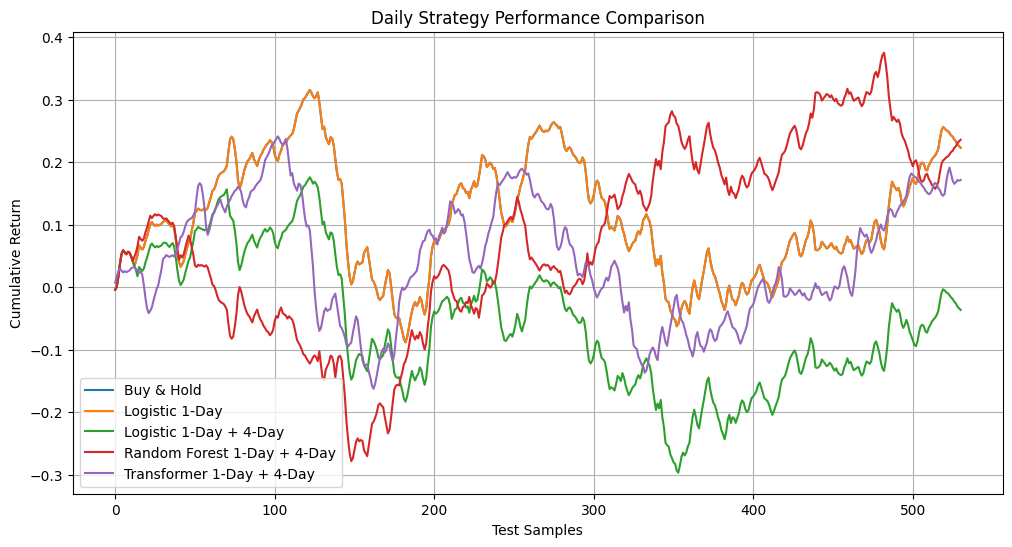

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(cum_buyhold_plot, label="Buy & Hold")
plt.plot(cum_lr_single_plot, label="Logistic 1-Day")
plt.plot(cum_lr_multi_plot, label="Logistic 1-Day + 4-Day")
plt.plot(cum_rf_multi_plot, label="Random Forest 1-Day + 4-Day")
plt.plot(cum_tf_plot, label="Transformer 1-Day + 4-Day")

plt.title("Daily Strategy Performance Comparison")
plt.xlabel("Test Samples")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

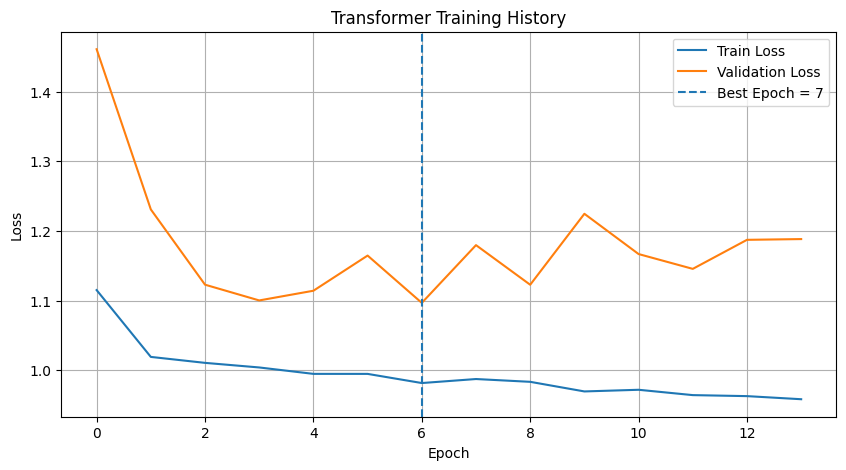

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.axvline(best_epoch - 1, linestyle="--", label=f"Best Epoch = {best_epoch}")
plt.title("Transformer Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

           Feature  Importance
12    macd_hist_4d    0.102182
1            ema30    0.081076
6           atr_1d    0.079280
0            ema10    0.078043
5     macd_hist_1d    0.076807
8         ema30_4d    0.076505
7         ema10_4d    0.072047
2           rsi_1d    0.070466
13          atr_4d    0.065163
9           rsi_4d    0.062178
11  macd_signal_4d    0.061606
3          macd_1d    0.059224
10         macd_4d    0.058333
4   macd_signal_1d    0.057091


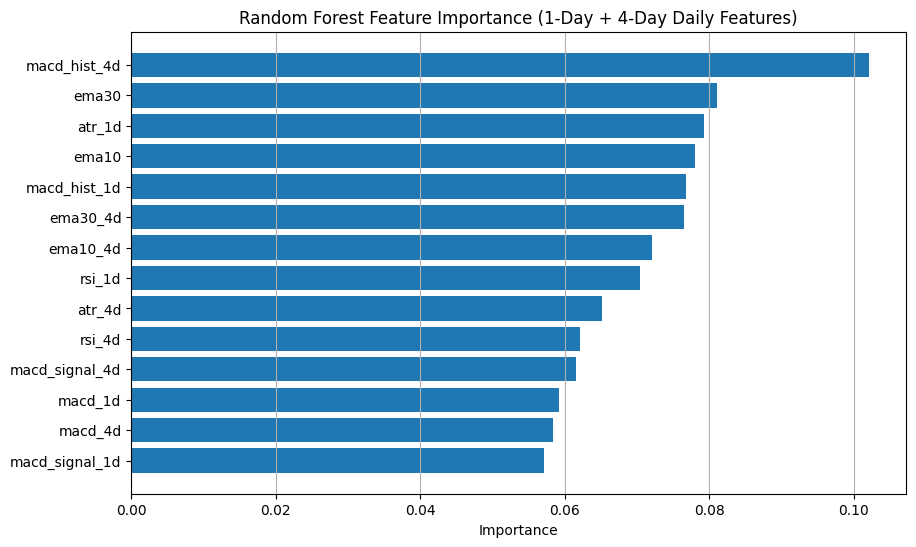

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": feature_cols_multi,
    "Importance": rf_multi.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance (1-Day + 4-Day Daily Features)")
plt.xlabel("Importance")
plt.grid(True, axis="x")
plt.show()

In [ ]:
results_cls.to_csv("classification_comparison_daily.csv", index=False)
results_bt.to_csv("backtest_comparison_daily.csv", index=False)
feature_importance.to_csv("rf_feature_importance_daily.csv", index=False)

print("Saved:")
print("- classification_comparison_daily.csv")
print("- backtest_comparison_daily.csv")
print("- rf_feature_importance_daily.csv")

Saved:
- classification_comparison_daily.csv
- backtest_comparison_daily.csv
- rf_feature_importance_daily.csv


# 9. Trading Strategy Backtesting(Trading Strategy Layer)

To evaluate practical usefulness, model predictions were converted into **trading signals**.

Trading rules:

- Prediction = 1 → Long position  
- Prediction = -1 → Short position  

Strategy returns were calculated by multiplying predicted direction with the actual future return.

The strategies were compared against a **Buy & Hold baseline strategy**.

In [ ]:
# =========================
# Live Feature Engineering and Signal Generation
# =========================

def build_live_features_daily(df_live):
  # Create a copy to avoid modifying the original dataframe
    df_live = df_live.copy()

    # Convert datetime column to proper datetime format
    df_live["datetime"] = pd.to_datetime(df_live["datetime"])
    # Sort data chronologically
    df_live = df_live.sort_values("datetime").reset_index(drop=True)

    # Compute mid price from bid and ask close prices
    df_live["mid_price"] = (df_live["bid_close"] + df_live["ask_close"]) / 2

    # Daily trend indicators
    df_live["ema10"] = ema(df_live["mid_price"], 10)
    df_live["ema30"] = ema(df_live["mid_price"], 30)

    df_live["rsi_1d"] = rsi(df_live["mid_price"], 14)

    # Daily MACD components
    df_live["macd_1d"], df_live["macd_signal_1d"], df_live["macd_hist_1d"] = macd(df_live["mid_price"])

    df_live["atr_1d"] = atr_proxy(df_live["mid_price"], 14)

    df_live["ema10_4d"] = df_live["ema10"].rolling(4).mean()
    df_live["ema30_4d"] = df_live["ema30"].rolling(4).mean()

    df_live["rsi_4d"] = df_live["rsi_1d"].rolling(4).mean()

    df_live["macd_4d"] = df_live["macd_1d"].rolling(4).mean()
    df_live["macd_signal_4d"] = df_live["macd_signal_1d"].rolling(4).mean()
    df_live["macd_hist_4d"] = df_live["macd_hist_1d"].rolling(4).mean()

    df_live["atr_4d"] = df_live["atr_1d"].rolling(4).mean()

    df_live = df_live.dropna(subset=feature_cols_multi).reset_index(drop=True)
    return df_live

def get_live_signal_daily(df_live, model, scaler, confidence_threshold=0.55, sl_atr_mult=1.0, tp_atr_mult=2.0):
    # Build live features from raw market data
    df_feat = build_live_features_daily(df_live)

    # Return error if there is not enough data to compute indicators
    if len(df_feat) == 0:
        return {"error": "Not enough rows to compute features."}

    # Select the most recent row for prediction
    latest = df_feat.iloc[[-1]].copy()
    # Scale features using the fitted training scaler
    X_latest = scaler.transform(latest[feature_cols_multi])

    # Predict trading class
    pred_class = int(model.predict(X_latest)[0])

    # Extract confidence if the model supports probability output
    confidence = None
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_latest)[0]
        class_index = list(model.classes_).index(pred_class)
        confidence = float(probs[class_index])

    # Get current market price and volatility
    current_price = float(latest["mid_price"].iloc[0])
    current_atr = float(latest["atr_1d"].iloc[0])


    # Return NO TRADE if model confidence is below threshold
    if confidence is not None and confidence < confidence_threshold:
        return {
            "datetime": latest["datetime"].iloc[0],
            "signal": "NO TRADE",
            "confidence": round(confidence, 4),
            "entry_price": round(current_price, 5),
            "atr": round(current_atr, 5),
            "stop_loss": None,
            "take_profit": None,
            "risk_reward_ratio": None
        }

    # Generate LONG or SHORT signal and compute stop-loss / take-profit
    if pred_class == 1:
        signal = "LONG"
        stop_loss = current_price - sl_atr_mult * current_atr
        take_profit = current_price + tp_atr_mult * current_atr
    else:
        signal = "SHORT"
        stop_loss = current_price + sl_atr_mult * current_atr
        take_profit = current_price - tp_atr_mult * current_atr

    # Return structured trade signal output
    return {
        "datetime": latest["datetime"].iloc[0],
        "signal": signal,
        "confidence": None if confidence is None else round(confidence, 4),
        "entry_price": round(current_price, 5),
        "atr": round(current_atr, 5),
        "stop_loss": round(stop_loss, 5),
        "take_profit": round(take_profit, 5),
        "risk_reward_ratio": f"1:{tp_atr_mult/sl_atr_mult:.1f}"
    }

# Print live trade signal in a readable format
def print_signal(result):
    if "error" in result:
        print("Error:", result["error"])
        return

    print("========== LIVE TRADE SIGNAL ==========")
    print("Datetime      :", result["datetime"])
    print("Signal        :", result["signal"])
    print("Confidence    :", result["confidence"])
    print("Entry Price   :", result["entry_price"])
    print("ATR           :", result["atr"])
    print("Stop Loss     :", result["stop_loss"])
    print("Take Profit   :", result["take_profit"])
    print("Risk/Reward   :", result["risk_reward_ratio"])
    print("=======================================")

In [ ]:
# Example using the last 100 rows from df
df_live = df.tail(100)[["datetime", "bid_close", "ask_close"]].copy()

# You can choose the best model here.
# Example: use lr_multi (Logistic 1-Day + 4-Day)
result = get_live_signal_daily(
    df_live=df_live,
    model=lr_multi,
    scaler=scaler_multi,
    confidence_threshold=0.55,
    sl_atr_mult=1.0,
    tp_atr_mult=2.0
)

print_signal(result)

========== LIVE TRADE SIGNAL ==========
Datetime      : 2025-12-31 00:00:00
Signal        : LONG
Confidence    : 0.5552
Entry Price   : 156.67
ATR           : 0.79954
Stop Loss     : 155.87046
Take Profit   : 158.26907
Risk/Reward   : 1:2.0


In [ ]:
bid_file = "USD-JPY_Day_2026-01-01_to_2026-03-20_Asia_Kuala_Lumpur_BID.csv"
ask_file = "USD-JPY_Day_2026-01-01_to_2026-03-20_Asia_Kuala_Lumpur_ASK.csv"

bid_test = pd.read_csv(bid_file)
ask_test = pd.read_csv(ask_file)

bid_test.rename(columns={"Asia/Kuala_Lumpur": "datetime"}, inplace=True)
ask_test.rename(columns={"Asia/Kuala_Lumpur": "datetime"}, inplace=True)

for df in [bid_test, ask_test]:
    df["datetime"] = df["datetime"].astype(str).str.replace(" UTC\\+08:00", "", regex=True)
    df["datetime"] = pd.to_datetime(df["datetime"], dayfirst=True)

bid_test.rename(columns={"Close": "bid_close"}, inplace=True)
ask_test.rename(columns={"Close": "ask_close"}, inplace=True)

df_live = pd.merge(
    bid_test[["datetime", "bid_close"]],
    ask_test[["datetime", "ask_close"]],
    on="datetime",
    how="inner"
).sort_values("datetime").reset_index(drop=True)

df_live = df_live.tail(100).copy()

result = get_live_signal_daily(
    df_live=df_live,
    model=lr_multi,
    scaler=scaler_multi,
    confidence_threshold=0.55,
    sl_atr_mult=1.0,
    tp_atr_mult=2.0
)

print_signal(result)

========== LIVE TRADE SIGNAL ==========
Datetime      : 2026-03-20 00:00:00
Signal        : LONG
Confidence    : 0.5805
Entry Price   : 159.228
ATR           : 0.77645
Stop Loss     : 158.45155
Take Profit   : 160.78091
Risk/Reward   : 1:2.0


# 10. Visualization and Analysis

To interpret the results, several visualization techniques were used:

- Cumulative return comparison charts  
- Feature importance plots  
- Confusion matrices  
- Correlation heatmaps  

These visualizations help understand model behaviour and feature relationships.

           Feature  Importance
12    macd_hist_4d    0.102182
1            ema30    0.081076
6           atr_1d    0.079280
0            ema10    0.078043
5     macd_hist_1d    0.076807
8         ema30_4d    0.076505
7         ema10_4d    0.072047
2           rsi_1d    0.070466
13          atr_4d    0.065163
9           rsi_4d    0.062178
11  macd_signal_4d    0.061606
3          macd_1d    0.059224
10         macd_4d    0.058333
4   macd_signal_1d    0.057091


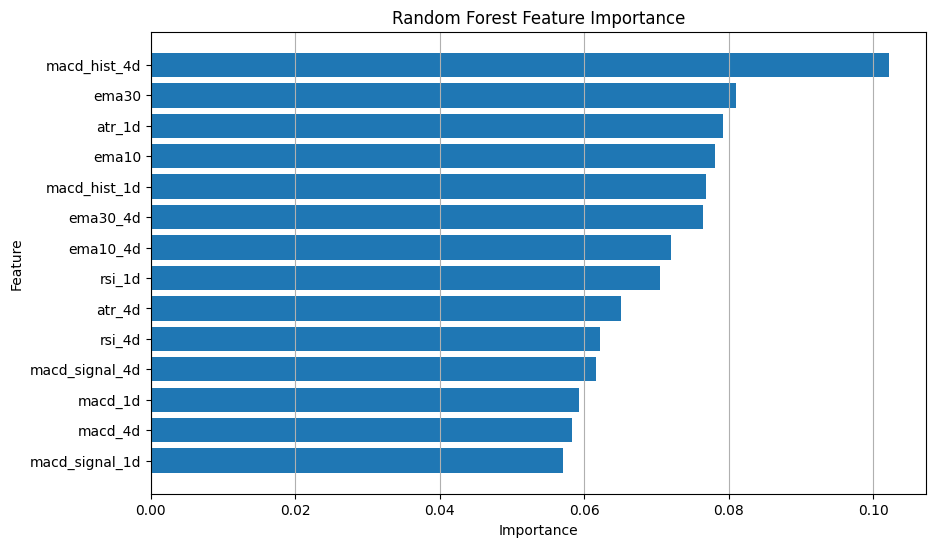

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": feature_cols_multi,
    "Importance": rf_multi.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True, axis="x")
plt.show()

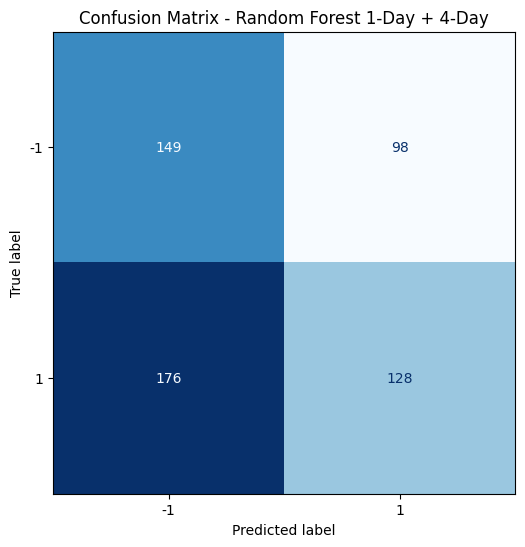

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test_compare, pred_rf_multi, labels=[-1, 1])

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=[-1, 1])

fig, ax = plt.subplots(figsize=(6, 6))
disp_rf.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Random Forest 1-Day + 4-Day")
plt.show()

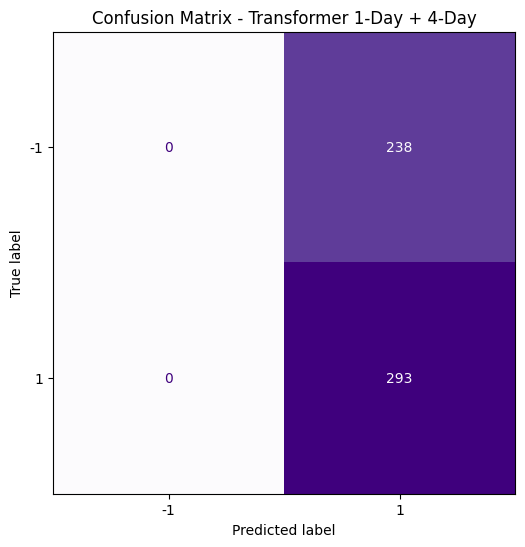

In [ ]:
cm_tf = confusion_matrix(y_test_seq, pred_tf, labels=[-1, 1])

disp_tf = ConfusionMatrixDisplay(confusion_matrix=cm_tf, display_labels=[-1, 1])

fig, ax = plt.subplots(figsize=(6, 6))
disp_tf.plot(ax=ax, cmap="Purples", colorbar=False)
plt.title("Confusion Matrix - Transformer 1-Day + 4-Day")
plt.show()

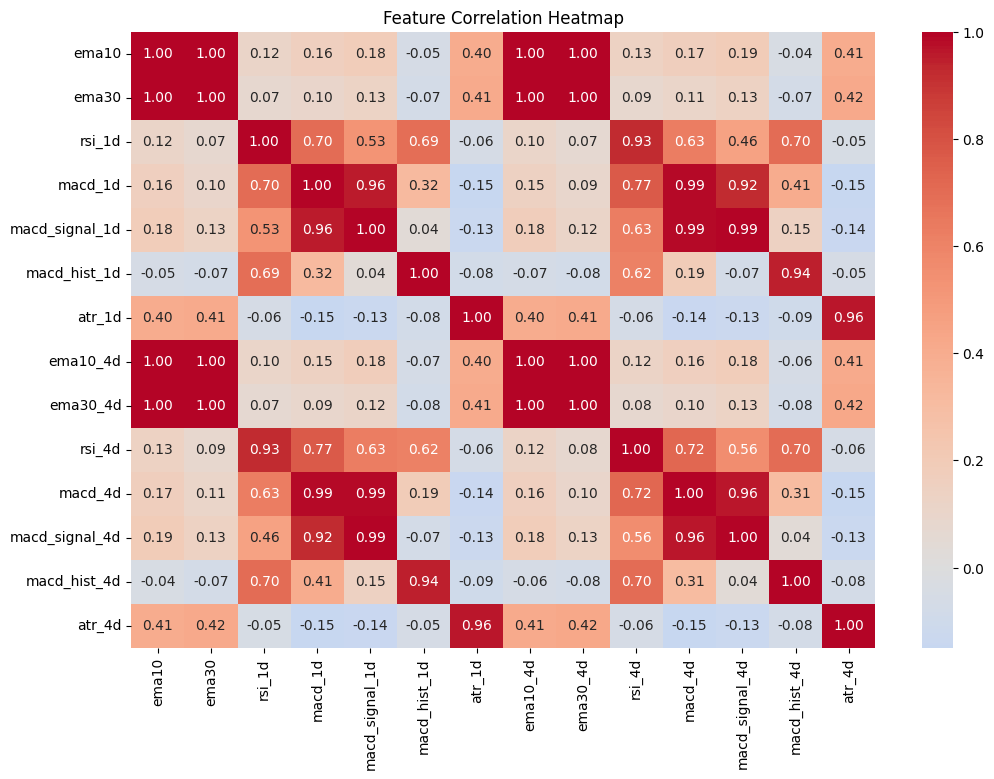

In [ ]:
import seaborn as sns

corr_matrix = df_compare[feature_cols_multi].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

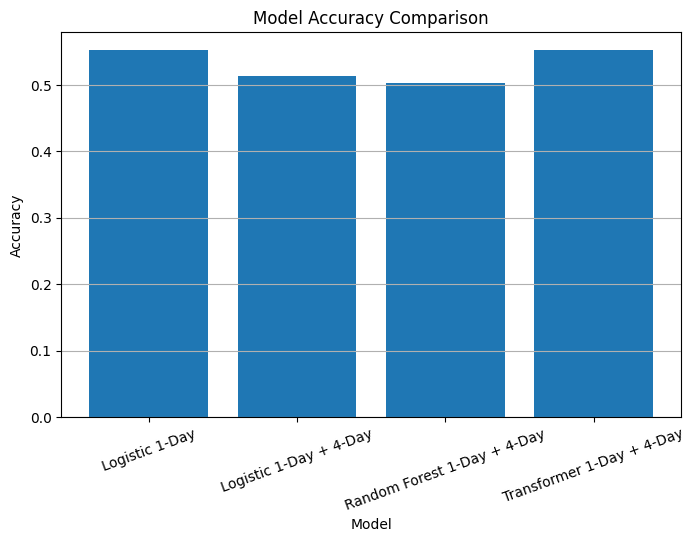

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results_cls["Model"], results_cls["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=20)
plt.grid(True, axis="y")
plt.show()

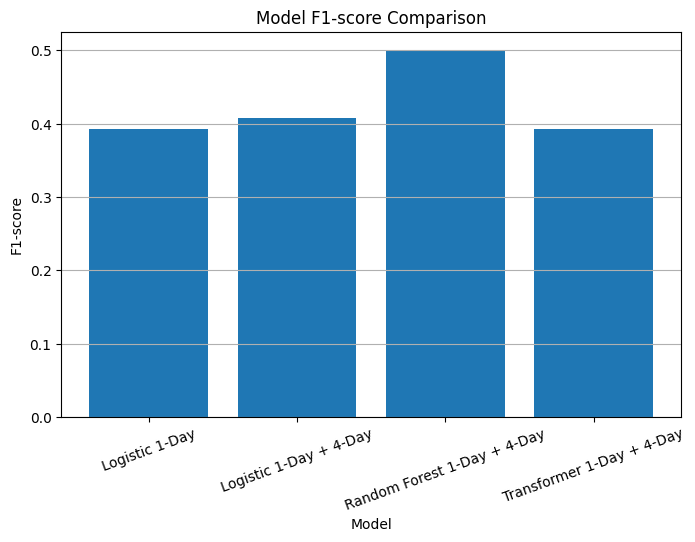

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results_cls["Model"], results_cls["F1-score"])
plt.title("Model F1-score Comparison")
plt.ylabel("F1-score")
plt.xlabel("Model")
plt.xticks(rotation=20)
plt.grid(True, axis="y")
plt.show()